In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

# Reproductibilité
torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device('cpu')
print("Environnement prêt !")
print(f"PyTorch version : {torch.__version__}")

Environnement prêt !
PyTorch version : 2.7.0+cpu


In [4]:
# Normalisation standard CIFAR-10
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

# Téléchargement automatique (~170 Mo, une seule fois)
train_set = torchvision.datasets.CIFAR10(root='./data', train=True,
                                          download=True, transform=transform)
test_set  = torchvision.datasets.CIFAR10(root='./data', train=False,
                                          download=True, transform=transform)

train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_set,  batch_size=128, shuffle=False)

CLASSES = ('avion','auto','oiseau','chat','cerf',
           'chien','grenouille','cheval','bateau','camion')

print(f"Train : {len(train_set)} images")
print(f"Test  : {len(test_set)} images")

c:\Users\oumal\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Train : 50000 images
Test  : 10000 images


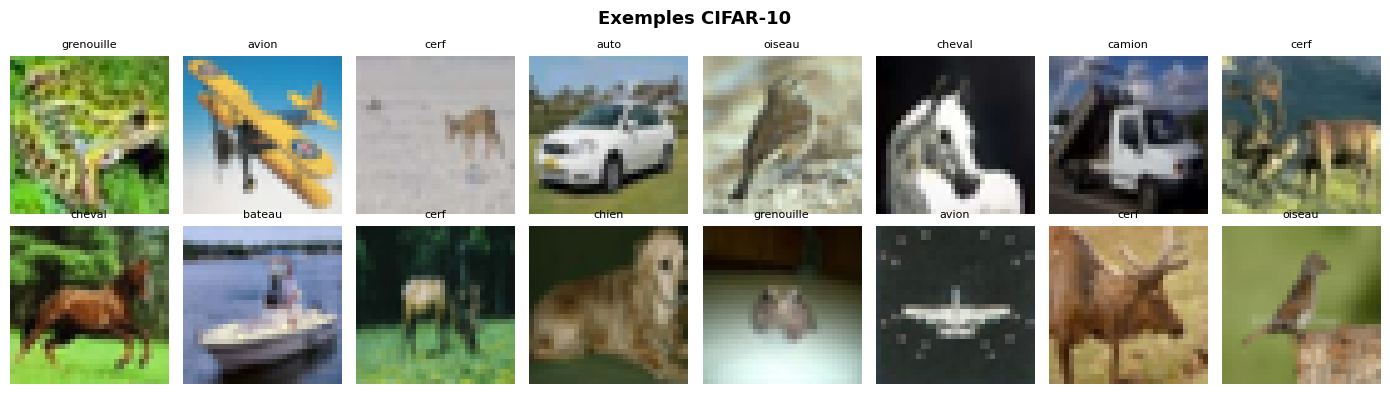

In [5]:
# Dénormalisation pour affichage
mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3,1,1)
std  = torch.tensor([0.2023, 0.1994, 0.2010]).view(3,1,1)

images, labels = next(iter(train_loader))  # un batch de 128

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    img = (images[i] * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(CLASSES[labels[i]], fontsize=8)
    ax.axis('off')

plt.suptitle('Exemples CIFAR-10', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_dataset.png', dpi=150)
plt.show()

In [6]:
# Une seule couche de neurones
couche = nn.Linear(3072, 1024)
print(couche)
print(f"Poids : {couche.weight.shape}")
print(f"Biais : {couche.bias.shape}")

Linear(in_features=3072, out_features=1024, bias=True)
Poids : torch.Size([1024, 3072])
Biais : torch.Size([1024])


In [7]:
une_image = images[0]
print("Forme de l'image :", une_image.shape)

Forme de l'image : torch.Size([3, 32, 32])


## MLP

In [8]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(3072, 1024)
        self.fc2 = nn.Linear(1024, 512)
        self.fc3 = nn.Linear(512, 256)
        self.fc4 = nn.Linear(256, 10)

    def forward(self, x):
        x = x.flatten(1)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = torch.relu(self.fc3(x))
        x = self.fc4(x)
        return x

# On recrée le modèle, la loss et l'optimizer
mlp = MLP()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(mlp.parameters(), lr=0.001)

print("Modèle prêt !")
print(mlp)

Modèle prêt !
MLP(
  (fc1): Linear(in_features=3072, out_features=1024, bias=True)
  (fc2): Linear(in_features=1024, out_features=512, bias=True)
  (fc3): Linear(in_features=512, out_features=256, bias=True)
  (fc4): Linear(in_features=256, out_features=10, bias=True)
)


In [9]:
mlp = MLP()
print(mlp)
print(f"\nNombre de paramètres : {sum(p.numel() for p in mlp.parameters()):,}")

MLP(
  (fc1): Linear(in_features=3072, out_features=1024, bias=True)
  (fc2): Linear(in_features=1024, out_features=512, bias=True)
  (fc3): Linear(in_features=512, out_features=256, bias=True)
  (fc4): Linear(in_features=256, out_features=10, bias=True)
)

Nombre de paramètres : 3,805,450


In [10]:
criterion = nn.CrossEntropyLoss()  # fonction de perte
optimizer = torch.optim.Adam(mlp.parameters(), lr=0.001)  # optimiseur

print("Loss :", criterion)
print("Optimizer :", optimizer)

Loss : CrossEntropyLoss()
Optimizer : Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [11]:
def entrainer(model, loader, criterion, optimizer):
    model.train()          # mode entraînement
    loss_totale = 0
    correct = 0
    total = 0

    for images, labels in loader:
        # 1. Prédiction
        predictions = model(images)

        # 2. Calcul de la loss
        loss = criterion(predictions, labels)

        # 3. On remet les gradients à zéro
        optimizer.zero_grad()

        # 4. Rétropropagation
        loss.backward()

        # 5. Mise à jour des poids
        optimizer.step()

        loss_totale += loss.item()
        correct += (predictions.argmax(1) == labels).sum().item()
        total += labels.size(0)

    accuracy = correct / total
    return loss_totale / len(loader), accuracy

In [12]:
def evaluer(model, loader, criterion):
    model.eval()           # mode évaluation
    loss_totale = 0
    correct = 0
    total = 0

    with torch.no_grad():  # on ne calcule pas les gradients
        for images, labels in loader:
            predictions = model(images)
            loss = criterion(predictions, labels)

            loss_totale += loss.item()
            correct += (predictions.argmax(1) == labels).sum().item()
            total += labels.size(0)

    accuracy = correct / total
    return loss_totale / len(loader), accuracy

In [13]:
EPOQUES = 20
historique = {'train_loss': [], 'train_acc': [], 'test_acc': []}

for epoque in range(EPOQUES):
    # Entraînement
    train_loss, train_acc = entrainer(mlp, train_loader, criterion, optimizer)
    
    # Évaluation
    test_loss, test_acc = evaluer(mlp, test_loader, criterion)
    
    # Sauvegarde des résultats
    historique['train_loss'].append(train_loss)
    historique['train_acc'].append(train_acc)
    historique['test_acc'].append(test_acc)
    
    print(f"Époque {epoque+1:2d}/{EPOQUES} | "
          f"Loss {train_loss:.3f} | "
          f"Train {train_acc:.3f} | "
          f"Test {test_acc:.3f}")

Époque  1/20 | Loss 1.669 | Train 0.405 | Test 0.462
Époque  2/20 | Loss 1.453 | Train 0.487 | Test 0.504
Époque  3/20 | Loss 1.343 | Train 0.525 | Test 0.513
Époque  4/20 | Loss 1.245 | Train 0.559 | Test 0.524
Époque  5/20 | Loss 1.163 | Train 0.585 | Test 0.529
Époque  6/20 | Loss 1.084 | Train 0.613 | Test 0.534
Époque  7/20 | Loss 1.013 | Train 0.637 | Test 0.532
Époque  8/20 | Loss 0.939 | Train 0.662 | Test 0.536
Époque  9/20 | Loss 0.884 | Train 0.684 | Test 0.540
Époque 10/20 | Loss 0.809 | Train 0.709 | Test 0.535
Époque 11/20 | Loss 0.751 | Train 0.729 | Test 0.538
Époque 12/20 | Loss 0.696 | Train 0.750 | Test 0.544
Époque 13/20 | Loss 0.652 | Train 0.765 | Test 0.536
Époque 14/20 | Loss 0.603 | Train 0.783 | Test 0.533
Époque 15/20 | Loss 0.558 | Train 0.801 | Test 0.527
Époque 16/20 | Loss 0.529 | Train 0.810 | Test 0.533
Époque 17/20 | Loss 0.493 | Train 0.822 | Test 0.535
Époque 18/20 | Loss 0.460 | Train 0.834 | Test 0.531
Époque 19/20 | Loss 0.446 | Train 0.840 | Test

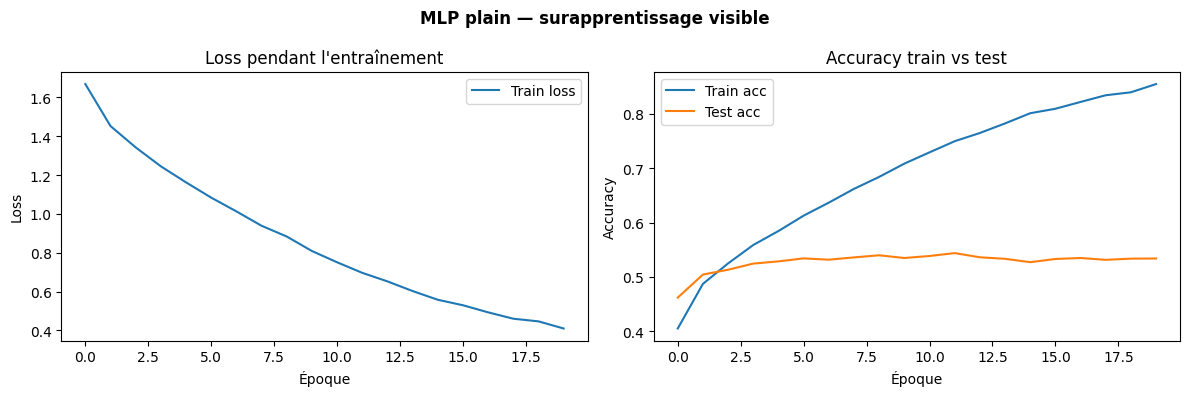

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Courbe de loss
axes[0].plot(historique['train_loss'], label='Train loss')
axes[0].set_title('Loss pendant l\'entraînement')
axes[0].set_xlabel('Époque')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Courbe d'accuracy
axes[1].plot(historique['train_acc'], label='Train acc')
axes[1].plot(historique['test_acc'],  label='Test acc')
axes[1].set_title('Accuracy train vs test')
axes[1].set_xlabel('Époque')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.suptitle('MLP plain — surapprentissage visible', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_mlp_plain.png', dpi=150)
plt.show()

Le MLP sans régularisation atteint une accuracy de 85.5% sur le train mais seulement 53.4% sur le test, soit un gap de 32.1 points. Ce surapprentissage massif s'explique par deux facteurs : le grand nombre de paramètres (3,8M) et l'absence de mécanisme de régularisation. La courbe de test stagne dès l'époque 5, indiquant que le réseau mémorise les données d'entraînement plutôt que d'apprendre des représentations généralisables

In [15]:
class MLP_Dropout(nn.Module):
    def __init__(self, dropout=0.4):
        super().__init__()
        self.fc1 = nn.Linear(3072, 1024)
        self.fc2 = nn.Linear(1024, 512)
        self.fc3 = nn.Linear(512, 256)
        self.fc4 = nn.Linear(256, 10)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        x = x.flatten(1)
        x = self.drop(torch.relu(self.fc1(x)))
        x = self.drop(torch.relu(self.fc2(x)))
        x = self.drop(torch.relu(self.fc3(x)))
        x = self.fc4(x)
        return x

mlp_drop = MLP_Dropout(dropout=0.4)
criterion_drop = nn.CrossEntropyLoss()
optimizer_drop = torch.optim.Adam(mlp_drop.parameters(), lr=0.001)

print("MLP avec dropout prêt !")

MLP avec dropout prêt !


In [16]:
EPOQUES = 20
historique_drop = {'train_loss': [], 'train_acc': [], 'test_acc': []}

for epoque in range(EPOQUES):
    train_loss, train_acc = entrainer(mlp_drop, train_loader, criterion_drop, optimizer_drop)
    test_loss, test_acc = evaluer(mlp_drop, test_loader, criterion_drop)
    
    historique_drop['train_loss'].append(train_loss)
    historique_drop['train_acc'].append(train_acc)
    historique_drop['test_acc'].append(test_acc)
    
    print(f"Époque {epoque+1:2d}/{EPOQUES} | "
          f"Loss {train_loss:.3f} | "
          f"Train {train_acc:.3f} | "
          f"Test {test_acc:.3f}")

Époque  1/20 | Loss 1.856 | Train 0.336 | Test 0.423
Époque  2/20 | Loss 1.705 | Train 0.395 | Test 0.443
Époque  3/20 | Loss 1.653 | Train 0.416 | Test 0.457
Époque  4/20 | Loss 1.620 | Train 0.428 | Test 0.463
Époque  5/20 | Loss 1.591 | Train 0.442 | Test 0.472
Époque  6/20 | Loss 1.570 | Train 0.450 | Test 0.450
Époque  7/20 | Loss 1.548 | Train 0.456 | Test 0.486
Époque  8/20 | Loss 1.531 | Train 0.463 | Test 0.493
Époque  9/20 | Loss 1.511 | Train 0.470 | Test 0.490
Époque 10/20 | Loss 1.501 | Train 0.472 | Test 0.488
Époque 11/20 | Loss 1.480 | Train 0.481 | Test 0.503
Époque 12/20 | Loss 1.468 | Train 0.483 | Test 0.491
Époque 13/20 | Loss 1.453 | Train 0.490 | Test 0.491
Époque 14/20 | Loss 1.440 | Train 0.497 | Test 0.504
Époque 15/20 | Loss 1.424 | Train 0.499 | Test 0.511
Époque 16/20 | Loss 1.413 | Train 0.503 | Test 0.504
Époque 17/20 | Loss 1.405 | Train 0.507 | Test 0.510
Époque 18/20 | Loss 1.390 | Train 0.517 | Test 0.505
Époque 19/20 | Loss 1.383 | Train 0.517 | Test

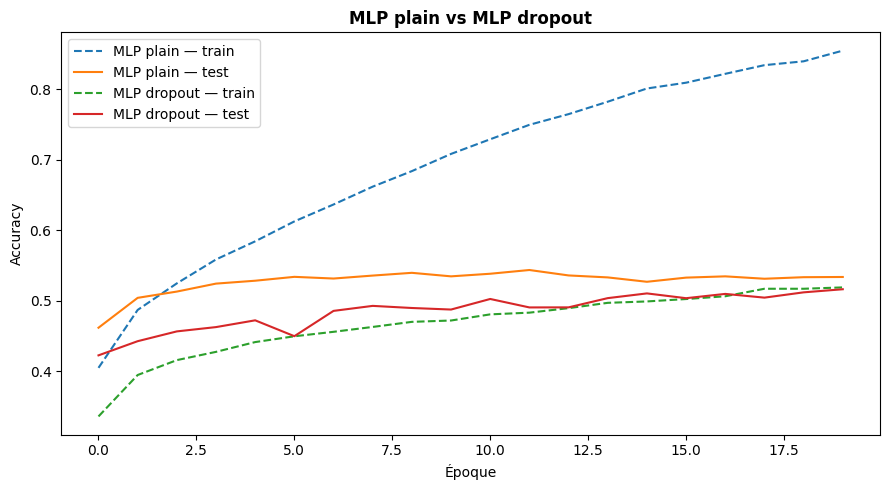

In [20]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(historique['train_acc'],      label='MLP plain — train', linestyle='--')
ax.plot(historique['test_acc'],       label='MLP plain — test')
ax.plot(historique_drop['train_acc'], label='MLP dropout — train', linestyle='--')
ax.plot(historique_drop['test_acc'],  label='MLP dropout — test')

ax.set_title('MLP plain vs MLP dropout', fontweight='bold')
ax.set_xlabel('Époque')
ax.set_ylabel('Accuracy')
ax.legend()
plt.tight_layout()
plt.savefig('fig_mlp_comparaison.png', dpi=150)
plt.show()

Le dropout (p=0.4) réduit drastiquement le surapprentissage : le gap train/test passe de 32.1 points à 0.3 points. Cependant, l'accuracy sur le test reste similaire (51.6% vs 53.4%), ce qui montre que la régularisation seule ne suffit pas à améliorer la généralisation du MLP. La limite est structurelle : en aplatissant l'image en un vecteur de 3072 valeurs, le MLP perd toute notion de proximité spatiale entre pixels. C'est cette limite fondamentale qui motive l'utilisation d'un CNN.

In [21]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        # Bloc 1 : 3×32×32 → 64×16×16
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(64)
        
        # Bloc 2 : 64×16×16 → 128×8×8
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(128)
        
        # Bloc 3 : 128×8×8 → 256×4×4
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm2d(256)
        
        # Classification
        self.fc = nn.Linear(256 * 4 * 4, 10)

    def forward(self, x):
        # Bloc 1
        x = self.conv1(x)
        x = self.bn1(x)
        x = torch.relu(x)
        x = torch.max_pool2d(x, 2)   # 32×32 → 16×16

        # Bloc 2
        x = self.conv2(x)
        x = self.bn2(x)
        x = torch.relu(x)
        x = torch.max_pool2d(x, 2)   # 16×16 → 8×8

        # Bloc 3
        x = self.conv3(x)
        x = self.bn3(x)
        x = torch.relu(x)
        x = torch.max_pool2d(x, 2)   # 8×8 → 4×4

        # Classification
        x = x.flatten(1)             # 256×4×4 → 4096
        x = self.fc(x)
        return x


# Vérification
cnn = CNN()
print(cnn)
print(f"\nNombre de paramètres : {sum(p.numel() for p in cnn.parameters()):,}")

CNN(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc): Linear(in_features=4096, out_features=10, bias=True)
)

Nombre de paramètres : 412,682


In [22]:
cnn = CNN()
criterion_cnn = nn.CrossEntropyLoss()
optimizer_cnn = torch.optim.Adam(cnn.parameters(), lr=0.001)

EPOQUES = 20
historique_cnn = {'train_loss': [], 'train_acc': [], 'test_acc': []}

for epoque in range(EPOQUES):
    train_loss, train_acc = entrainer(cnn, train_loader, criterion_cnn, optimizer_cnn)
    test_loss, test_acc   = evaluer(cnn, test_loader, criterion_cnn)
    
    historique_cnn['train_loss'].append(train_loss)
    historique_cnn['train_acc'].append(train_acc)
    historique_cnn['test_acc'].append(test_acc)
    
    print(f"Époque {epoque+1:2d}/{EPOQUES} | "
          f"Loss {train_loss:.3f} | "
          f"Train {train_acc:.3f} | "
          f"Test {test_acc:.3f}")

Époque  1/20 | Loss 1.228 | Train 0.570 | Test 0.646
Époque  2/20 | Loss 0.812 | Train 0.717 | Test 0.716
Époque  3/20 | Loss 0.660 | Train 0.770 | Test 0.755
Époque  4/20 | Loss 0.550 | Train 0.812 | Test 0.755
Époque  5/20 | Loss 0.456 | Train 0.844 | Test 0.749
Époque  6/20 | Loss 0.372 | Train 0.873 | Test 0.777
Époque  7/20 | Loss 0.295 | Train 0.901 | Test 0.785
Époque  8/20 | Loss 0.229 | Train 0.923 | Test 0.769
Époque  9/20 | Loss 0.173 | Train 0.944 | Test 0.769
Époque 10/20 | Loss 0.137 | Train 0.957 | Test 0.786
Époque 11/20 | Loss 0.105 | Train 0.968 | Test 0.779
Époque 12/20 | Loss 0.064 | Train 0.984 | Test 0.794
Époque 13/20 | Loss 0.055 | Train 0.987 | Test 0.728
Époque 14/20 | Loss 0.082 | Train 0.974 | Test 0.753
Époque 15/20 | Loss 0.083 | Train 0.973 | Test 0.783
Époque 16/20 | Loss 0.034 | Train 0.992 | Test 0.799
Époque 17/20 | Loss 0.015 | Train 0.998 | Test 0.800
Époque 18/20 | Loss 0.013 | Train 0.998 | Test 0.802
Époque 19/20 | Loss 0.118 | Train 0.961 | Test

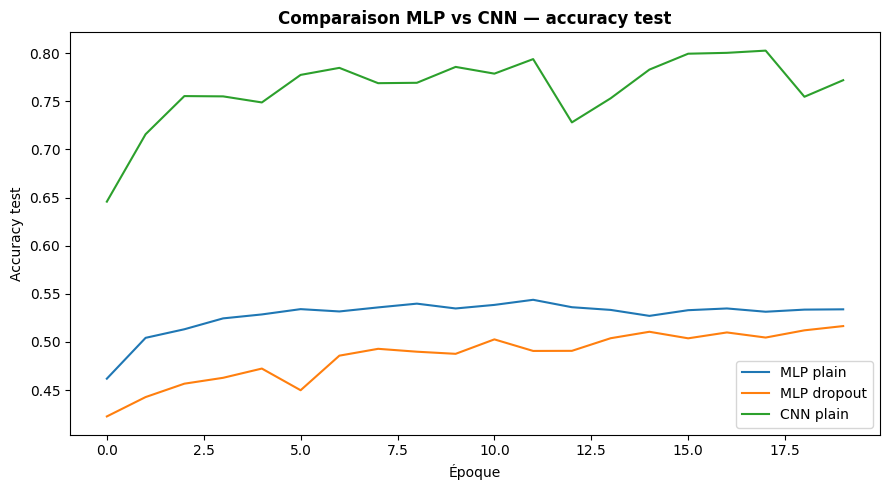

In [23]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(historique['test_acc'],     label='MLP plain')
ax.plot(historique_drop['test_acc'],label='MLP dropout')
ax.plot(historique_cnn['test_acc'], label='CNN plain')

ax.set_title('Comparaison MLP vs CNN — accuracy test', fontweight='bold')
ax.set_xlabel('Époque')
ax.set_ylabel('Accuracy test')
ax.legend()
plt.tight_layout()
plt.savefig('fig_mlp_vs_cnn.png', dpi=150)
plt.show()

Le CNN surpasse largement le MLP sur CIFAR-10, atteignant 81.4% d'accuracy sur le test contre 53.4% pour le meilleur MLP, soit un gain de 28 points. Ce résultat s'explique par le biais inductif convolutif : les filtres 3×3 partagés sur toute l'image permettent de détecter des motifs locaux (bords, textures, formes) tout en préservant la structure spatiale. Paradoxalement, le CNN obtient ce résultat avec 10 fois moins de paramètres (412K vs 3.8M), ce qui confirme que l'architecture est plus importante que la taille du modèle pour les données images

In [24]:
transform_augmente = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

train_set_aug = torchvision.datasets.CIFAR10(root='./data', train=True,
                                              download=False,
                                              transform=transform_augmente)

train_loader_aug = DataLoader(train_set_aug, batch_size=128, shuffle=True)

print("Dataset augmenté prêt !")
print(f"Nombre d'images : {len(train_set_aug)}")

Dataset augmenté prêt !
Nombre d'images : 50000


In [25]:
cnn_aug = CNN()
criterion_aug = nn.CrossEntropyLoss()
optimizer_aug = torch.optim.Adam(cnn_aug.parameters(), lr=0.001)

EPOQUES = 20
historique_cnn_aug = {'train_loss': [], 'train_acc': [], 'test_acc': []}

for epoque in range(EPOQUES):
    train_loss, train_acc = entrainer(cnn_aug, train_loader_aug, criterion_aug, optimizer_aug)
    test_loss, test_acc   = evaluer(cnn_aug, test_loader, criterion_aug)
    
    historique_cnn_aug['train_loss'].append(train_loss)
    historique_cnn_aug['train_acc'].append(train_acc)
    historique_cnn_aug['test_acc'].append(test_acc)
    
    print(f"Époque {epoque+1:2d}/{EPOQUES} | "
          f"Loss {train_loss:.3f} | "
          f"Train {train_acc:.3f} | "
          f"Test {test_acc:.3f}")

Époque  1/20 | Loss 1.468 | Train 0.474 | Test 0.637
Époque  2/20 | Loss 1.058 | Train 0.627 | Test 0.679
Époque  3/20 | Loss 0.908 | Train 0.685 | Test 0.720
Époque  4/20 | Loss 0.819 | Train 0.716 | Test 0.721
Époque  5/20 | Loss 0.758 | Train 0.738 | Test 0.762
Époque  6/20 | Loss 0.711 | Train 0.756 | Test 0.748
Époque  7/20 | Loss 0.669 | Train 0.769 | Test 0.778
Époque  8/20 | Loss 0.637 | Train 0.780 | Test 0.787
Époque  9/20 | Loss 0.604 | Train 0.792 | Test 0.805
Époque 10/20 | Loss 0.590 | Train 0.796 | Test 0.796
Époque 11/20 | Loss 0.552 | Train 0.809 | Test 0.816
Époque 12/20 | Loss 0.529 | Train 0.817 | Test 0.795
Époque 13/20 | Loss 0.517 | Train 0.821 | Test 0.800
Époque 14/20 | Loss 0.497 | Train 0.829 | Test 0.808
Époque 15/20 | Loss 0.478 | Train 0.836 | Test 0.813
Époque 16/20 | Loss 0.462 | Train 0.839 | Test 0.832
Époque 17/20 | Loss 0.449 | Train 0.845 | Test 0.808
Époque 18/20 | Loss 0.435 | Train 0.850 | Test 0.828
Époque 19/20 | Loss 0.423 | Train 0.854 | Test

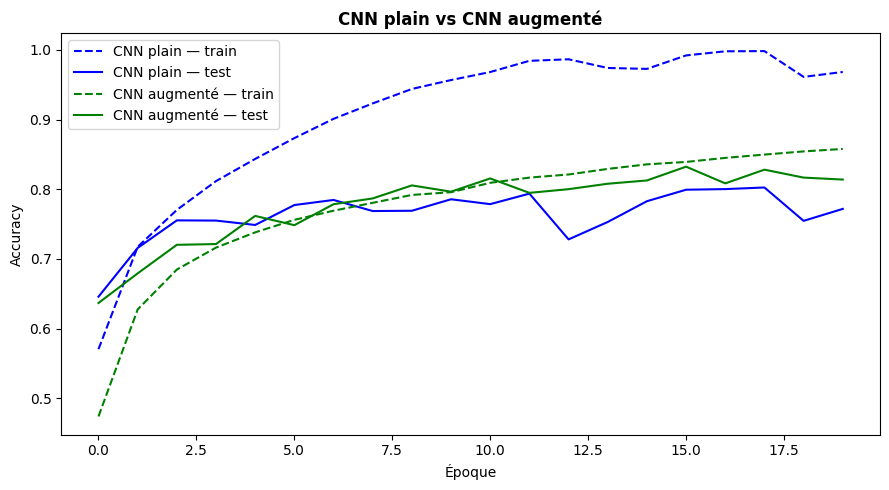

In [26]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(historique_cnn['train_acc'],     label='CNN plain — train', linestyle='--', color='blue')
ax.plot(historique_cnn['test_acc'],      label='CNN plain — test', color='blue')
ax.plot(historique_cnn_aug['train_acc'], label='CNN augmenté — train', linestyle='--', color='green')
ax.plot(historique_cnn_aug['test_acc'],  label='CNN augmenté — test', color='green')

ax.set_title('CNN plain vs CNN augmenté', fontweight='bold')
ax.set_xlabel('Époque')
ax.set_ylabel('Accuracy')
ax.legend()
plt.tight_layout()
plt.savefig('fig_cnn_augmentation.png', dpi=150)
plt.show()

In [27]:
import pandas as pd

resultats = {
    'Modèle': ['MLP plain', 'MLP dropout', 'CNN plain', 'CNN augmenté'],
    'Paramètres': ['3 805 450', '3 805 450', '412 682', '412 682'],
    'Acc. train': [0.855, 0.519, 1.000, 0.857],
    'Acc. test':  [0.534, 0.516, 0.814, 0.833],
    'Gap':        [0.321, 0.003, 0.186, 0.024]
}

df = pd.DataFrame(resultats)
print(df.to_string(index=False))

      Modèle Paramètres  Acc. train  Acc. test   Gap
   MLP plain  3 805 450       0.855      0.534 0.321
 MLP dropout  3 805 450       0.519      0.516 0.003
   CNN plain    412 682       1.000      0.814 0.186
CNN augmenté    412 682       0.857      0.833 0.024


1. Le CNN fait +28 points par rapport au MLP avec 10x moins de paramètres → l'architecture compte plus que la taille
2. Le dropout réduit le surapprentissage du MLP mais ne l'améliore pas vraiment → la limite est structurelle
3. La data augmentation réduit le gap du CNN de 0.186 à 0.024 tout en améliorant le test → c'est le meilleur régulariseur qu'on a testé

# PARTIE 2

In [28]:
def tester_robustesse(model, loader, sigmas):
    """
    Évalue l'accuracy du modèle sous différents niveaux de bruit gaussien.
    sigma = intensité du bruit (0 = pas de bruit)
    """
    resultats = []

    for sigma in sigmas:
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in loader:
                # On ajoute le bruit gaussien
                bruit = torch.randn_like(images) * sigma
                images_bruitees = images + bruit

                predictions = model(images_bruitees)
                correct += (predictions.argmax(1) == labels).sum().item()
                total += labels.size(0)

        accuracy = correct / total
        resultats.append(accuracy)
        print(f"σ = {sigma:.2f} | Accuracy : {accuracy:.3f}")

    return resultats


sigmas = [0.0, 0.1, 0.2, 0.3, 0.5, 0.75, 1.0]

In [29]:
print("=== MLP dropout ===")
acc_mlp = tester_robustesse(mlp_drop, test_loader, sigmas)

print("\n=== CNN augmenté ===")
acc_cnn = tester_robustesse(cnn_aug, test_loader, sigmas)

=== MLP dropout ===
σ = 0.00 | Accuracy : 0.516
σ = 0.10 | Accuracy : 0.517
σ = 0.20 | Accuracy : 0.518
σ = 0.30 | Accuracy : 0.514
σ = 0.50 | Accuracy : 0.511
σ = 0.75 | Accuracy : 0.505
σ = 1.00 | Accuracy : 0.499

=== CNN augmenté ===
σ = 0.00 | Accuracy : 0.814
σ = 0.10 | Accuracy : 0.795
σ = 0.20 | Accuracy : 0.658
σ = 0.30 | Accuracy : 0.471
σ = 0.50 | Accuracy : 0.271
σ = 0.75 | Accuracy : 0.193
σ = 1.00 | Accuracy : 0.149


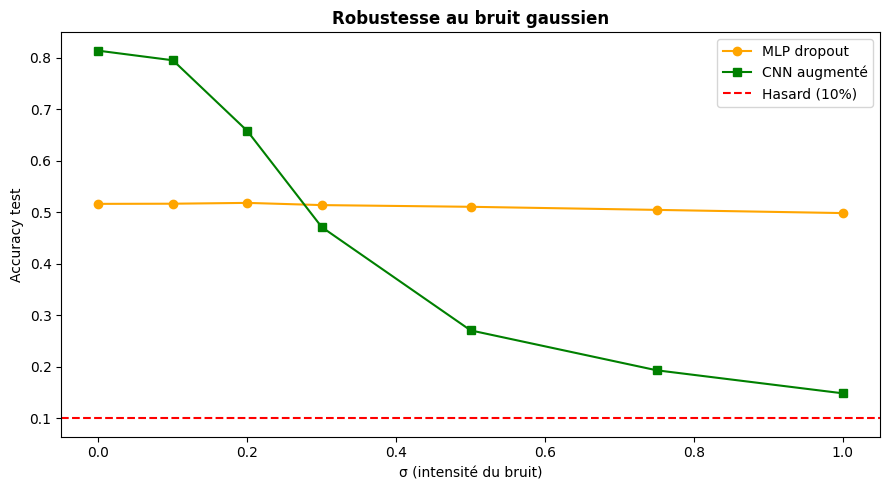

In [30]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(sigmas, acc_mlp, 'o-', label='MLP dropout', color='orange')
ax.plot(sigmas, acc_cnn, 's-', label='CNN augmenté', color='green')
ax.axhline(y=0.1, color='red', linestyle='--', label='Hasard (10%)')

ax.set_title('Robustesse au bruit gaussien', fontweight='bold')
ax.set_xlabel('σ (intensité du bruit)')
ax.set_ylabel('Accuracy test')
ax.legend()
plt.tight_layout()
plt.savefig('fig_robustesse.png', dpi=150)
plt.show()

## VAE

In [31]:
LATENT_DIM = 128  # taille de l'espace latent

class Encodeur(nn.Module):
    def __init__(self):
        super().__init__()
        
        # Couches convolutives pour extraire les features
        self.conv = nn.Sequential(
            nn.Conv2d(3, 64, 4, stride=2, padding=1),   # 3×32×32 → 64×16×16
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, stride=2, padding=1), # 64×16×16 → 128×8×8
            nn.ReLU(),
            nn.Conv2d(128, 256, 4, stride=2, padding=1),# 128×8×8 → 256×4×4
            nn.ReLU()
        )
        
        # Deux têtes : une pour mu, une pour log_var
        self.fc_mu      = nn.Linear(256 * 4 * 4, LATENT_DIM)
        self.fc_log_var = nn.Linear(256 * 4 * 4, LATENT_DIM)

    def forward(self, x):
        h = self.conv(x).flatten(1)  # extraire les features
        mu      = self.fc_mu(h)      # moyenne
        log_var = self.fc_log_var(h) # log variance
        return mu, log_var

# Test
enc = Encodeur()
print(enc)

Encodeur(
  (conv): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
  )
  (fc_mu): Linear(in_features=4096, out_features=128, bias=True)
  (fc_log_var): Linear(in_features=4096, out_features=128, bias=True)
)


In [32]:
class Decodeur(nn.Module):
    def __init__(self):
        super().__init__()
        
        # On part de z et on remonte vers une image
        self.fc = nn.Linear(LATENT_DIM, 256 * 4 * 4)
        
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1), # 256×4×4 → 128×8×8
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),  # 128×8×8 → 64×16×16
            nn.ReLU(),
            nn.ConvTranspose2d(64, 3, 4, stride=2, padding=1),    # 64×16×16 → 3×32×32
            nn.Tanh()
        )

    def forward(self, z):
        h = self.fc(z).view(-1, 256, 4, 4)  # reshape en volume 3D
        return self.deconv(h)

# Test
dec = Decodeur()
print(dec)

Decodeur(
  (fc): Linear(in_features=128, out_features=4096, bias=True)
  (deconv): Sequential(
    (0): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): Tanh()
  )
)


In [33]:
class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encodeur = Encodeur()
        self.decodeur = Decodeur()

    def reparametrize(self, mu, log_var):
        # z = mu + epsilon * sigma
        sigma = torch.exp(0.5 * log_var)
        epsilon = torch.randn_like(sigma)
        return mu + epsilon * sigma

    def forward(self, x):
        mu, log_var = self.encodeur(x)
        z = self.reparametrize(mu, log_var)
        x_reconstruit = self.decodeur(z)
        return x_reconstruit, mu, log_var

    def encode(self, x):
        mu, _ = self.encodeur(x)
        return mu  # on utilise mu comme représentation

vae = VAE()
print(f"Paramètres VAE : {sum(p.numel() for p in vae.parameters()):,}")

Paramètres VAE : 2,894,723


In [34]:
def vae_loss(x, x_reconstruit, mu, log_var):
    # Partie 1 : reconstruction
    recon = F.mse_loss(x_reconstruit, x, reduction='sum') / x.size(0)
    
    # Partie 2 : KL divergence
    kl = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp()) / x.size(0)
    
    return recon + kl, recon.item(), kl.item()

import torch.nn.functional as F
print("Loss VAE définie !")

Loss VAE définie !


In [35]:
transform_vae = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # → valeurs entre -1 et 1
])

train_vae = torchvision.datasets.CIFAR10(root='./data', train=True,
                                          download=False, transform=transform_vae)
test_vae  = torchvision.datasets.CIFAR10(root='./data', train=False,
                                          download=False, transform=transform_vae)

loader_train_vae = DataLoader(train_vae, batch_size=128, shuffle=True)
loader_test_vae  = DataLoader(test_vae,  batch_size=128, shuffle=False)

print("Données VAE prêtes !")

c:\Users\oumal\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Données VAE prêtes !


In [38]:
def entrainer_vae(model, loader, optimizer, epochs=30):
    historique = {'total': [], 'recon': [], 'kl': []}

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        total_recon = 0
        total_kl = 0
        n = 0

        for images, _ in loader:  # on ignore les labels
            optimizer.zero_grad()
            
            # Passage avant
            x_reconstruit, mu, log_var = model(images)
            
            # Calcul de la loss
            loss, recon, kl = vae_loss(images, x_reconstruit, mu, log_var)
            
            # Rétropropagation
            loss.backward()
            optimizer.step()

            total_loss  += loss.item() * images.size(0)
            total_recon += recon * images.size(0)
            total_kl    += kl * images.size(0)
            n += images.size(0)

        historique['total'].append(total_loss / n)
        historique['recon'].append(total_recon / n)
        historique['kl'].append(total_kl / n)

        if (epoch + 1) % 5 == 0:
            print(f"Époque {epoch+1:3d}/{epochs} | "
                  f"Total {historique['total'][-1]:.2f} | "
                  f"Recon {historique['recon'][-1]:.2f} | "
                  f"KL {historique['kl'][-1]:.2f}")

    return historique

In [39]:
vae = VAE()
optimizer_vae = torch.optim.Adam(vae.parameters(), lr=3e-4)

print("Lancement de l'entraînement du VAE...")
h_vae = entrainer_vae(vae, loader_train_vae, optimizer_vae, epochs=30)

Lancement de l'entraînement du VAE...
Époque   5/30 | Total 196.49 | Recon 137.26 | KL 59.23
Époque  10/30 | Total 187.88 | Recon 125.33 | KL 62.55
Époque  15/30 | Total 184.49 | Recon 120.53 | KL 63.96
Époque  20/30 | Total 182.46 | Recon 117.83 | KL 64.64
Époque  25/30 | Total 181.18 | Recon 115.96 | KL 65.21
Époque  30/30 | Total 180.22 | Recon 114.77 | KL 65.45


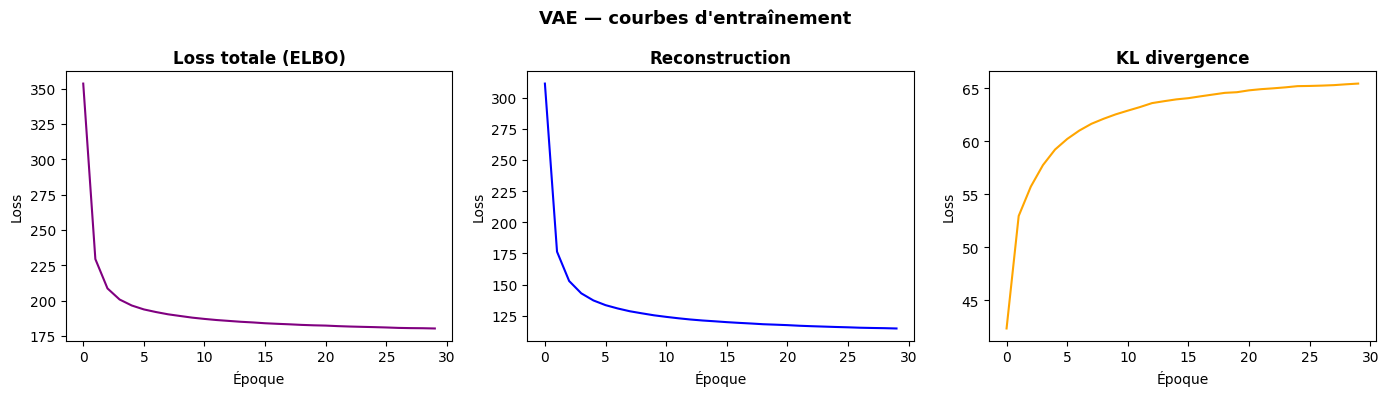

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, key, title, color in zip(axes,
                                  ['total', 'recon', 'kl'],
                                  ['Loss totale (ELBO)', 'Reconstruction', 'KL divergence'],
                                  ['purple', 'blue', 'orange']):
    ax.plot(h_vae[key], color=color)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Époque')
    ax.set_ylabel('Loss')

plt.suptitle('VAE — courbes d\'entraînement', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_vae_loss.png', dpi=150)
plt.show()

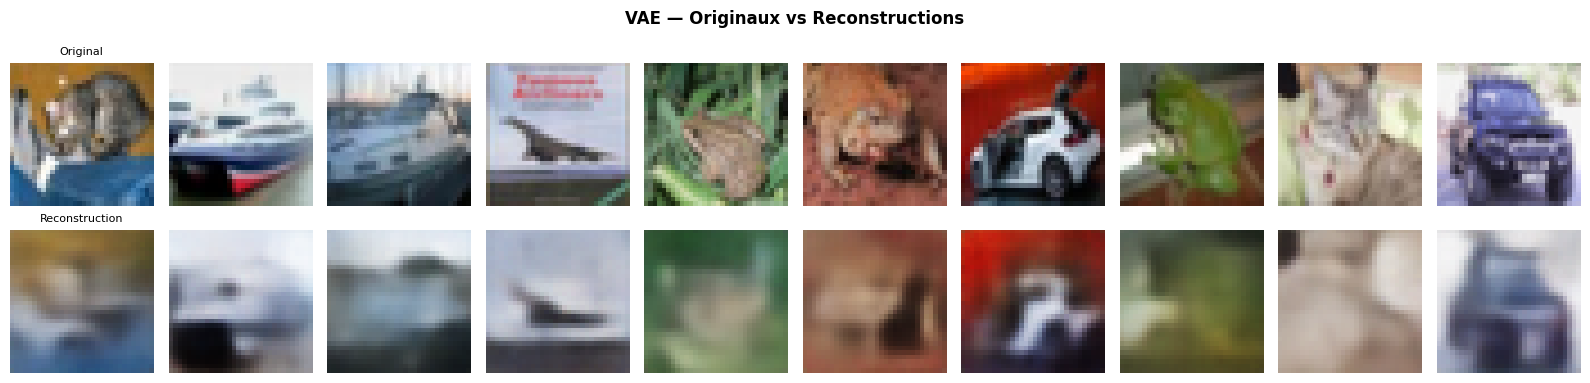

In [41]:
def denorm(t):
    """Dénormalise de [-1,1] vers [0,1] pour affichage."""
    return ((t * 0.5) + 0.5).clamp(0, 1)

vae.eval()
images_test, _ = next(iter(loader_test_vae))
images_test = images_test[:10]

with torch.no_grad():
    reconstructions, _, _ = vae(images_test)

fig, axes = plt.subplots(2, 10, figsize=(16, 4))
for i in range(10):
    # Ligne 1 : images originales
    axes[0, i].imshow(denorm(images_test[i]).permute(1,2,0).numpy())
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_title('Original', fontsize=8)

    # Ligne 2 : reconstructions
    axes[1, i].imshow(denorm(reconstructions[i]).permute(1,2,0).numpy())
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_title('Reconstruction', fontsize=8)

plt.suptitle('VAE — Originaux vs Reconstructions', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_vae_reconstructions.png', dpi=150)
plt.show()

Le VAE parvient à reconstruire les caractéristiques globales des images : couleurs dominantes, forme générale et structure de la scène sont préservées. Cependant, les reconstructions sont sensiblement floues comparées aux originaux. Ce flou est une limite inhérente à la loss de reconstruction MSE, qui pousse le décodeur à produire une moyenne des images plausibles plutôt qu'une image précise. Une loss perceptuelle basée sur les features d'un réseau pré-entraîné permettrait d'obtenir des reconstructions plus nettes.

In [42]:
from sklearn.manifold import TSNE

def extraire_latent(model, loader, n=2000):
    """Extrait les représentations latentes mu pour n images."""
    model.eval()
    zs, ys = [], []
    with torch.no_grad():
        for images, labels in loader:
            mu = model.encode(images)
            zs.append(mu)
            ys.append(labels)
            if sum(len(z) for z in zs) >= n:
                break
    return torch.cat(zs)[:n].numpy(), torch.cat(ys)[:n].numpy()

print("Extraction des représentations latentes...")
Z, Y = extraire_latent(vae, loader_test_vae, n=2000)
print(f"Forme de Z : {Z.shape}")
print(f"Forme de Y : {Y.shape}")

Extraction des représentations latentes...
Forme de Z : (2000, 128)
Forme de Y : (2000,)


In [43]:
print("Calcul du t-SNE (patience ~2 minutes)...")
tsne = TSNE(n_components=2, perplexity=40, random_state=42, n_iter=1000)
Z_2d = tsne.fit_transform(Z)

print(f"Forme après t-SNE : {Z_2d.shape}")

Calcul du t-SNE (patience ~2 minutes)...


TypeError: TSNE.__init__() got an unexpected keyword argument 'n_iter'